In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sonar.all-data",header=None)
df.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
94,0.0025,0.0309,0.0171,0.0228,0.0434,0.1224,0.1947,0.1661,0.1368,0.1430,...,0.0149,0.0077,0.0036,0.0114,0.0085,0.0101,0.0016,0.0028,0.0014,R
48,0.0190,0.0038,0.0642,0.0452,0.0333,0.0690,0.0901,0.1454,0.0740,0.0349,...,0.0093,0.0118,0.0112,0.0094,0.0140,0.0072,0.0022,0.0055,0.0122,R
112,0.0454,0.0472,0.0697,0.1021,0.1397,0.1493,0.1487,0.0771,0.1171,0.1675,...,0.0120,0.0042,0.0238,0.0129,0.0084,0.0218,0.0321,0.0154,0.0053,M
87,0.0856,0.0454,0.0382,0.0203,0.0385,0.0534,0.2140,0.3110,0.2837,0.2751,...,0.0172,0.0138,0.0079,0.0037,0.0051,0.0258,0.0102,0.0037,0.0037,R
178,0.0197,0.0394,0.0384,0.0076,0.0251,0.0629,0.0747,0.0578,0.1357,0.1695,...,0.0134,0.0097,0.0042,0.0058,0.0072,0.0041,0.0045,0.0047,0.0054,M


In [3]:
len(df.columns)

61

In [4]:
df[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

In [5]:
df[60] = df[60].map({"R":1,"M":0})

In [6]:
X = df.drop(60,axis=1)
y = df[60]

In [7]:
type(y)

pandas.core.series.Series

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=1)

In [9]:
type(X_train.values)

numpy.ndarray

In [10]:
X_train_tensor = torch.tensor(X_train.values,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.long)

In [11]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [12]:
train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=False)

### Simple Neural Network

In [13]:
for a,b in train_loader:
    print (a,b)
    break

tensor([[0.0790, 0.0707, 0.0352, 0.1660, 0.1330, 0.0226, 0.0771, 0.2678, 0.5664,
         0.6609, 0.5002, 0.2583, 0.1650, 0.4347, 0.4515, 0.4579, 0.3366, 0.4000,
         0.5325, 0.9010, 0.9939, 0.3689, 0.1012, 0.0248, 0.2318, 0.3981, 0.2259,
         0.5247, 0.6898, 0.8316, 0.4326, 0.3741, 0.5756, 0.8043, 0.7963, 0.7174,
         0.7056, 0.8148, 0.7601, 0.6034, 0.4554, 0.4729, 0.4478, 0.3722, 0.4693,
         0.3839, 0.0768, 0.1467, 0.0777, 0.0469, 0.0193, 0.0298, 0.0390, 0.0294,
         0.0175, 0.0249, 0.0141, 0.0073, 0.0025, 0.0101],
        [0.0258, 0.0433, 0.0547, 0.0681, 0.0784, 0.1250, 0.1296, 0.1729, 0.2794,
         0.2954, 0.2506, 0.2601, 0.2249, 0.2115, 0.1270, 0.1193, 0.1794, 0.2185,
         0.1646, 0.0740, 0.0625, 0.2381, 0.4824, 0.6372, 0.7531, 0.8959, 0.9941,
         0.9957, 0.9328, 0.9344, 0.8854, 0.7690, 0.6865, 0.6390, 0.6378, 0.6629,
         0.5983, 0.4565, 0.3129, 0.4158, 0.4325, 0.4031, 0.4201, 0.4557, 0.3955,
         0.2966, 0.2095, 0.1558, 0.0884, 0.0265, 0.

In [14]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(60,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,2)
        )
    def forward(self,x):
        return self.network(x)

#### Model Training

In [15]:
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [16]:
def train_test_model(model,criterion,optimizer,train_loader,test_loader,epochs=20):
    model.train()
    epochs = 20
    train_losses,val_losses,val_accuracies = [],[],[]
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for inputs,labels in train_loader:
            optimizer.zero_grad()
            predictions = model(inputs)
            loss = criterion(predictions,labels)
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_batch_loss = epoch_loss/len(train_loader)
        train_losses.append(avg_batch_loss)
    
        model.eval()
        with torch.no_grad():
            running_val_loss = 0.0
            true_lables,all_pred = [],[]
            for inputs,labels in test_loader:
                outputs = model(inputs)
                val_loss = criterion(outputs,labels)
                running_val_loss += val_loss.item()
                _,pred = torch.max(outputs,1)
                true_lables.extend(labels.cpu().numpy())
                all_pred.extend(pred.cpu().numpy())
            val_losses.append(running_val_loss/len(test_loader))
            val_accuracy = accuracy_score(true_lables,all_pred)
            val_accuracies.append(val_accuracy)
        print(f"Epoch: {epoch+1}/{epochs}, Training_Loss: { train_losses[-1]: .4f}, val_loss: {val_losses[-1] :.4f}, val_accuracy: {val_accuracies[-1]:.4f}")
    return train_losses,val_losses,val_accuracies

#### NN without dropout layer

In [17]:
train_losses,val_losses,val_accuracies =  train_test_model(model,criterion,optimizer,train_loader,test_loader,epochs=20)

Epoch: 1/20, Training_Loss:  0.6895, val_loss: 0.6741, val_accuracy: 0.5192
Epoch: 2/20, Training_Loss:  0.6790, val_loss: 0.6571, val_accuracy: 0.5192
Epoch: 3/20, Training_Loss:  0.6633, val_loss: 0.6415, val_accuracy: 0.6346
Epoch: 4/20, Training_Loss:  0.6443, val_loss: 0.6280, val_accuracy: 0.7692
Epoch: 5/20, Training_Loss:  0.6126, val_loss: 0.5872, val_accuracy: 0.6538
Epoch: 6/20, Training_Loss:  0.5788, val_loss: 0.5697, val_accuracy: 0.7692
Epoch: 7/20, Training_Loss:  0.5504, val_loss: 0.5464, val_accuracy: 0.7692
Epoch: 8/20, Training_Loss:  0.5043, val_loss: 0.5127, val_accuracy: 0.7115
Epoch: 9/20, Training_Loss:  0.4659, val_loss: 0.5300, val_accuracy: 0.7500
Epoch: 10/20, Training_Loss:  0.4229, val_loss: 0.4899, val_accuracy: 0.7115
Epoch: 11/20, Training_Loss:  0.4091, val_loss: 0.5035, val_accuracy: 0.7500
Epoch: 12/20, Training_Loss:  0.3930, val_loss: 0.4642, val_accuracy: 0.7500
Epoch: 13/20, Training_Loss:  0.3932, val_loss: 0.4779, val_accuracy: 0.7115
Epoch: 1

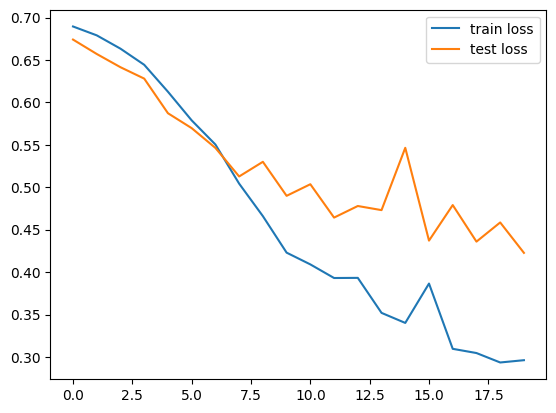

In [18]:
plt.plot(train_losses,label="train loss")
plt.plot(val_losses,label="test loss")
plt.legend()
plt.show()

### model with dropout layer

In [19]:
class nn_with_dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(60,128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64,2),
        )
    def forward(self,x):
        return self.network(x)

In [20]:
model_with_dropout = nn_with_dropout()
optimizer = optim.Adam(model_with_dropout.parameters(),lr=0.001)

In [21]:

train_loss_dropout,val_loss_dropout,val_acc_dropout = train_test_model(model_with_dropout,criterion,optimizer,train_loader,test_loader,epochs=20)

Epoch: 1/20, Training_Loss:  0.6992, val_loss: 0.6795, val_accuracy: 0.5769
Epoch: 2/20, Training_Loss:  0.6801, val_loss: 0.6669, val_accuracy: 0.5192
Epoch: 3/20, Training_Loss:  0.6758, val_loss: 0.6526, val_accuracy: 0.5192
Epoch: 4/20, Training_Loss:  0.6696, val_loss: 0.6443, val_accuracy: 0.5192
Epoch: 5/20, Training_Loss:  0.6540, val_loss: 0.6393, val_accuracy: 0.6346
Epoch: 6/20, Training_Loss:  0.6619, val_loss: 0.6301, val_accuracy: 0.6538
Epoch: 7/20, Training_Loss:  0.6457, val_loss: 0.6122, val_accuracy: 0.6346
Epoch: 8/20, Training_Loss:  0.6339, val_loss: 0.6009, val_accuracy: 0.6731
Epoch: 9/20, Training_Loss:  0.6185, val_loss: 0.5914, val_accuracy: 0.7115
Epoch: 10/20, Training_Loss:  0.6007, val_loss: 0.5882, val_accuracy: 0.7885
Epoch: 11/20, Training_Loss:  0.5757, val_loss: 0.5536, val_accuracy: 0.6731
Epoch: 12/20, Training_Loss:  0.5486, val_loss: 0.5617, val_accuracy: 0.8077
Epoch: 13/20, Training_Loss:  0.5492, val_loss: 0.5298, val_accuracy: 0.7115
Epoch: 1

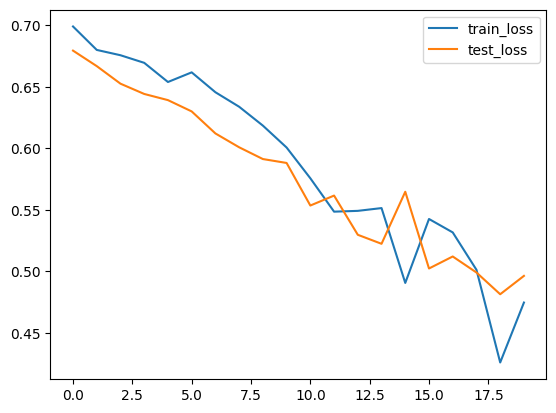

In [22]:
plt.plot(train_loss_dropout,label="train_loss")
plt.plot(val_loss_dropout,label="test_loss")
plt.legend()
plt.show()
